# Scikit-learn model adapters for `mnplib`

This notebook demonstrates the modular scikit-learn adapter package for the simplified `mnplib` classes.

The core metric classes remain model-agnostic:

- `Miscoding` works with a selected feature subset.
- `Inaccuracy` works with predictions.
- `Surfeit` works with a model-description string.
- `Nescience` combines the three explicit artifacts.

The adapter layer converts supported scikit-learn models into those artifacts:

```python
model + X_eval -> subset, predictions, model_string
```

Supported models in this first implementation:

- `DecisionTreeClassifier`
- `DecisionTreeRegressor`
- `LinearRegression`
- `Ridge`
- `Lasso`
- `ElasticNet`
- `LogisticRegression`


## 1. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_regression
from sklearn.dummy import DummyRegressor
from sklearn.exceptions import NotFittedError
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

from mnplib.nescience import Nescience
from mnplib.models import (
    SerializationConfig,
    components_model,
    explain_model,
    nescience_model,
    score_model,
    sklearn_model_artifacts,
)
from mnplib.models.sklearn import registry

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 5)

## 2. Supported models and canonical schema

The adapter package uses a registry of serializer classes. Each serializer extracts:

1. the feature subset used by the model;
2. the predictions on an evaluation dataset;
3. a canonical string representation of the fitted model.

All model strings use the same schema:

```text
SCHEMA canonical_nescience_model_v1
MODEL <EstimatorClass>
TASK <classification|regression>
INPUTS <selected feature names>
PARAMETERS
    ...
RULE
    ...
```


In [2]:
print("Registered serializers:")
print(registry.serializer_names())

print("\nSupported model types:")
for model_type in registry.supported_model_types():
    print("-", model_type.__name__)


Registered serializers:
('decision_tree', 'linear_model', 'logistic_regression')

Supported model types:
- DecisionTreeClassifier
- DecisionTreeRegressor
- LinearRegression
- Ridge
- Lasso
- ElasticNet
- LogisticRegression


## 3. Helper functions for tables and plots

In [3]:
def regression_row(name, model, metric, X_eval, y_eval, *, feature_names=None, config=None):
    """Return one comparison row for a regression model."""
    artifacts = sklearn_model_artifacts(
        model,
        X_eval,
        feature_names=feature_names,
        config=config,
    )
    components = metric.components(**artifacts.to_nescience_kwargs())

    return {
        "model": name,
        "r2": r2_score(y_eval, artifacts.predictions),
        "rmse": mean_squared_error(y_eval, artifacts.predictions) ** 0.5,
        "nescience": metric.aggregate_components(**components),
        **components,
        "n_features_in_use": len(artifacts.subset),
        "description_length": len(artifacts.model_string.encode("utf-8")),
        "model_type": artifacts.model_type,
    }


def classification_row(name, model, metric, X_eval, y_eval, *, feature_names=None, config=None):
    """Return one comparison row for a classification model."""
    artifacts = sklearn_model_artifacts(
        model,
        X_eval,
        feature_names=feature_names,
        config=config,
    )
    components = metric.components(**artifacts.to_nescience_kwargs())

    return {
        "model": name,
        "accuracy": accuracy_score(y_eval, artifacts.predictions),
        "nescience": metric.aggregate_components(**components),
        **components,
        "n_features_in_use": len(artifacts.subset),
        "description_length": len(artifacts.model_string.encode("utf-8")),
        "model_type": artifacts.model_type,
    }


def plot_components(df, title):
    """Plot the four nescience components."""
    component_cols = ["deficiency", "surplus", "inaccuracy", "surfeit"]
    df.set_index("model")[component_cols].plot(kind="bar", figsize=(12, 5))
    plt.ylabel("Component value")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()


def plot_nescience(df, title):
    """Plot scalar nescience values."""
    df.set_index("model")["nescience"].plot(kind="bar", figsize=(10, 4))
    plt.ylabel("Nescience")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()


def explanation_row(name, model, metric, X_eval, *, feature_names=None, config=None):
    """Return one compact explanation row."""
    explanation = explain_model(
        metric,
        model,
        X_eval,
        feature_names=feature_names,
        config=config,
    )
    return {
        "model": name,
        "nescience": explanation["nescience"],
        "dominant_component": explanation["dominant_component"],
        "profile": explanation["profile"],
        "model_type": explanation["model_type"],
        "n_features_in_use": explanation["model_metadata"]["n_features_in_use"],
    }


## 4. Regression example: tree versus linear models

This example compares five regression estimators using the same canonical serialization schema:

- `DecisionTreeRegressor`
- `LinearRegression`
- `Ridge`
- `Lasso`
- `ElasticNet`

The models are trained on the training split. Nescience is evaluated on the test split, so the internal `Nescience` object is fitted on `(X_test, y_test)`.


In [4]:
X, y = make_regression(
    n_samples=800,
    n_features=8,
    n_informative=3,
    noise=12.0,
    random_state=42,
)

feature_names = [f"x{i}" for i in range(X.shape[1])]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.35,
    random_state=42,
)

regression_models = {
    "tree_depth_3": DecisionTreeRegressor(max_depth=3, random_state=42),
    "linear": LinearRegression(),
    "ridge": Ridge(alpha=10.0),
    "lasso": Lasso(alpha=0.05, max_iter=10000),
    "elastic_net": ElasticNet(alpha=0.05, l1_ratio=0.5, max_iter=10000),
}

for model in regression_models.values():
    model.fit(X_train, y_train)

config = SerializationConfig(precision=4, include_metadata=True)

regression_metric = Nescience(
    X_type="numeric",
    y_type="numeric",
    aggregation="euclidean",
    n_bins="auto",
).fit(X_test, y_test)

regression_results = pd.DataFrame(
    [
        regression_row(
            name,
            model,
            regression_metric,
            X_test,
            y_test,
            feature_names=feature_names,
            config=config,
        )
        for name, model in regression_models.items()
    ]
).sort_values("nescience")

regression_results


,model,r2,rmse,nescience,deficiency,surplus,inaccuracy,surfeit,n_features_in_use,description_length,model_type
2,ridge,0.972073,11.978167,0.405118,0.000000,0.612468,0.364870,0.385013,8,387,Ridge
1,linear,0.972942,11.790322,0.405481,0.000000,0.612468,0.367960,0.383598,8,378,LinearRegression
4,elastic_net,0.971609,12.077208,0.406365,0.000000,0.612468,0.367866,0.387409,8,413,ElasticNet
3,lasso,0.972912,11.796777,0.407018,0.000000,0.612468,0.370906,0.387255,8,408,Lasso
0,tree_depth_3,0.764460,34.786240,0.563554,0.266797,0.626854,0.659880,0.608939,2,716,DecisionTreeRegressor


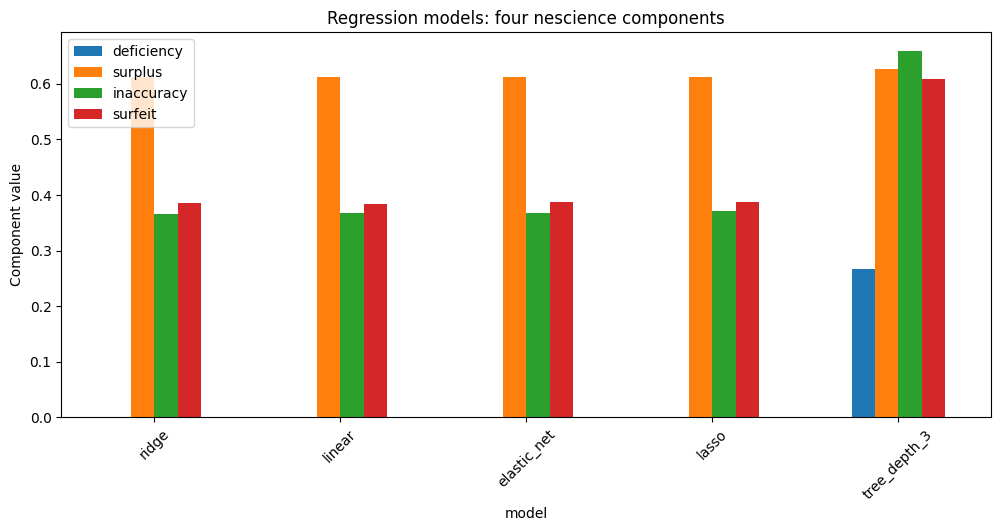

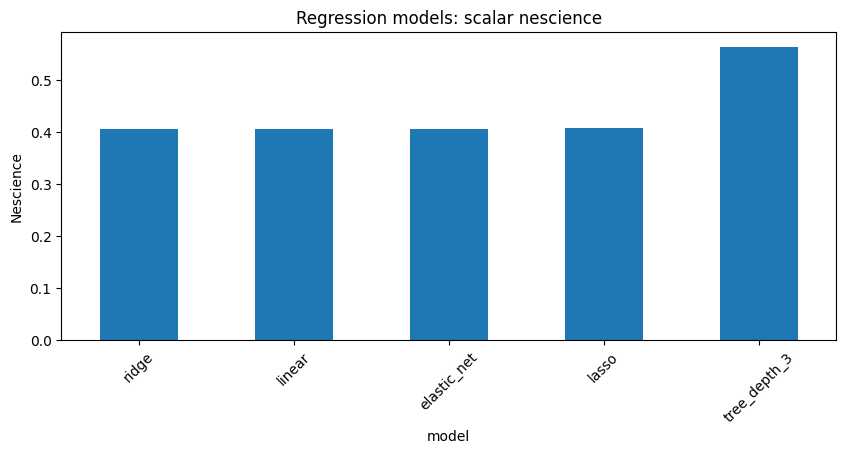

In [5]:
plot_components(regression_results, "Regression models: four nescience components")
plot_nescience(regression_results, "Regression models: scalar nescience")


### 4.1 Inspecting canonical model strings

The tree and the linear model are different model families, but both are serialized into the same canonical schema.


In [6]:
tree_artifacts = sklearn_model_artifacts(
    regression_models["tree_depth_3"],
    X_test,
    feature_names=feature_names,
    config=config,
)

linear_artifacts = sklearn_model_artifacts(
    regression_models["linear"],
    X_test,
    feature_names=feature_names,
    config=config,
)

print("DecisionTreeRegressor canonical string:")
print(tree_artifacts.model_string[:1800])

print("\nLinearRegression canonical string:")
print(linear_artifacts.model_string[:1800])


DecisionTreeRegressor canonical string:
SCHEMA canonical_nescience_model_v1
MODEL DecisionTreeRegressor
TASK regression
INPUTS x2, x4
PARAMETERS
    n_nodes = 15
    n_leaves = 8
    max_depth = 3
RULE
    if x2 <= -0.2659:
        if x2 <= -1.2673:
            if x4 <= 1.0031:
                return -122.8155
            else:
                return -57.6321
        else:
            if x4 <= 0.1545:
                return -63.2816
            else:
                return -24.7474
    else:
        if x2 <= 0.9877:
            if x4 <= -0.2003:
                return -2.0062
            else:
                return 38.1647
        else:
            if x2 <= 2.5506:
                return 87.9168
            else:
                return 193.9220


LinearRegression canonical string:
SCHEMA canonical_nescience_model_v1
MODEL LinearRegression
TASK regression
INPUTS x0, x1, x2, x3, x4, x5, x6, x7
PARAMETERS
    n_outputs = 1
    n_nonzero_coefficients = 8
RULE
    y = -1.0242
    y -= 0.37

### 4.2 Direct artifact workflow versus convenience wrapper

The adapter can be used explicitly through `sklearn_model_artifacts()`, or directly through `nescience_model()`.


In [7]:
model = regression_models["ridge"]

artifacts = sklearn_model_artifacts(
    model,
    X_test,
    feature_names=feature_names,
    config=config,
)

explicit_value = regression_metric.nescience(**artifacts.to_nescience_kwargs())

wrapper_value = nescience_model(
    regression_metric,
    model,
    X_test,
    feature_names=feature_names,
    config=config,
)

print("Explicit artifact workflow:", explicit_value)
print("Convenience wrapper:", wrapper_value)
print("Equal:", np.isclose(explicit_value, wrapper_value))


Explicit artifact workflow: 0.40511807147505496
Convenience wrapper: 0.40511807147505496
Equal: True


## 5. Classification example: decision tree versus logistic regression

In [8]:
Xc, yc = make_classification(
    n_samples=900,
    n_features=10,
    n_informative=4,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    class_sep=1.5,
    random_state=42,
)

classification_feature_names = [f"x{i}" for i in range(Xc.shape[1])]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc,
    yc,
    test_size=0.35,
    random_state=42,
    stratify=yc,
)

classification_models = {
    "tree_depth_3": DecisionTreeClassifier(max_depth=3, random_state=42),
    "tree_unrestricted": DecisionTreeClassifier(random_state=42),
    "logistic": LogisticRegression(max_iter=1000),
}

for model in classification_models.values():
    model.fit(Xc_train, yc_train)

classification_metric = Nescience(
    X_type="numeric",
    y_type="categorical",
    aggregation="euclidean",
    n_bins="auto",
).fit(Xc_test, yc_test)

classification_results = pd.DataFrame(
    [
        classification_row(
            name,
            model,
            classification_metric,
            Xc_test,
            yc_test,
            feature_names=classification_feature_names,
            config=config,
        )
        for name, model in classification_models.items()
    ]
).sort_values("nescience")

classification_results


,model,accuracy,nescience,deficiency,surplus,inaccuracy,surfeit,n_features_in_use,description_length,model_type
0,tree_depth_3,0.873016,0.607318,0.0,0.878959,0.547590,0.634757,5,679,DecisionTreeClassifier
2,logistic,0.819048,0.608186,0.0,0.879514,0.680863,0.492386,10,591,LogisticRegression
1,tree_unrestricted,0.863492,0.708785,0.0,0.879514,0.574643,0.951705,10,6522,DecisionTreeClassifier


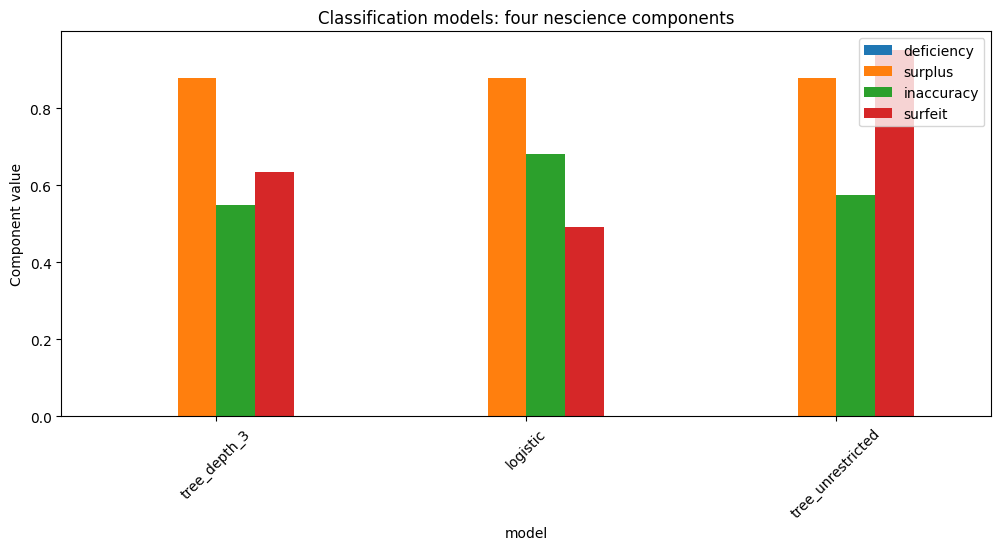

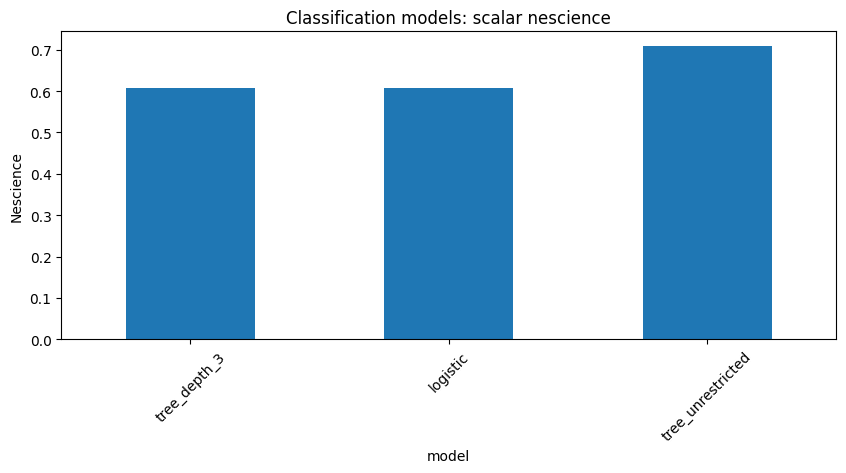

In [9]:
plot_components(classification_results, "Classification models: four nescience components")
plot_nescience(classification_results, "Classification models: scalar nescience")


## 6. Diagnostic explanations

`explain_model()` adds model metadata to the simplified `Nescience.explain(...)` output.


In [10]:
regression_explanations = pd.DataFrame(
    [
        explanation_row(
            name,
            model,
            regression_metric,
            X_test,
            feature_names=feature_names,
            config=config,
        )
        for name, model in regression_models.items()
    ]
).sort_values("nescience")

regression_explanations


,model,nescience,dominant_component,profile,model_type,n_features_in_use
2,ridge,0.405118,surplus,over_fed_model,Ridge,8
1,linear,0.405481,surplus,over_fed_model,LinearRegression,8
4,elastic_net,0.406365,surplus,over_fed_model,ElasticNet,8
3,lasso,0.407018,surplus,over_fed_model,Lasso,8
0,tree_depth_3,0.563554,inaccuracy,over_fed_model,DecisionTreeRegressor,2


In [11]:
classification_explanations = pd.DataFrame(
    [
        explanation_row(
            name,
            model,
            classification_metric,
            Xc_test,
            feature_names=classification_feature_names,
            config=config,
        )
        for name, model in classification_models.items()
    ]
).sort_values("nescience")

classification_explanations


,model,nescience,dominant_component,profile,model_type,n_features_in_use
0,tree_depth_3,0.607318,surplus,over_fed_model,DecisionTreeClassifier,5
2,logistic,0.608186,surplus,over_fed_model,LogisticRegression,10
1,tree_unrestricted,0.708785,surfeit,over_fed_model,DecisionTreeClassifier,10


## 7. Changing the practical objective with weights

The canonical adapter only extracts artifacts. The practical objective remains controlled by `Nescience`.

Here we compare three weight settings:

- balanced;
- accuracy-focused;
- simplicity-focused.


In [12]:
weight_settings = {
    "balanced": None,
    "accuracy_focused": {
        "deficiency": 1.0,
        "surplus": 1.0,
        "inaccuracy": 3.0,
        "surfeit": 1.0,
    },
    "simplicity_focused": {
        "deficiency": 1.0,
        "surplus": 2.0,
        "inaccuracy": 1.0,
        "surfeit": 3.0,
    },
}

weighted_rows = []

for setting_name, weights in weight_settings.items():
    weighted_metric = Nescience(
        X_type="numeric",
        y_type="numeric",
        aggregation="euclidean",
        weights=weights,
        n_bins="auto",
    ).fit(X_test, y_test)

    for model_name, model in regression_models.items():
        value = nescience_model(
            weighted_metric,
            model,
            X_test,
            feature_names=feature_names,
            config=config,
        )
        weighted_rows.append(
            {
                "setting": setting_name,
                "model": model_name,
                "nescience": value,
            }
        )

weighted_results = pd.DataFrame(weighted_rows)

weighted_results.pivot(
    index="model",
    columns="setting",
    values="nescience",
)


setting,accuracy_focused,balanced,simplicity_focused
model,,,
elastic_net,0.393950,0.406365,0.436842
lasso,0.395348,0.407018,0.437151
linear,0.393372,0.405481,0.435410
ridge,0.392161,0.405118,0.435574
tree_depth_3,0.597391,0.563554,0.586141


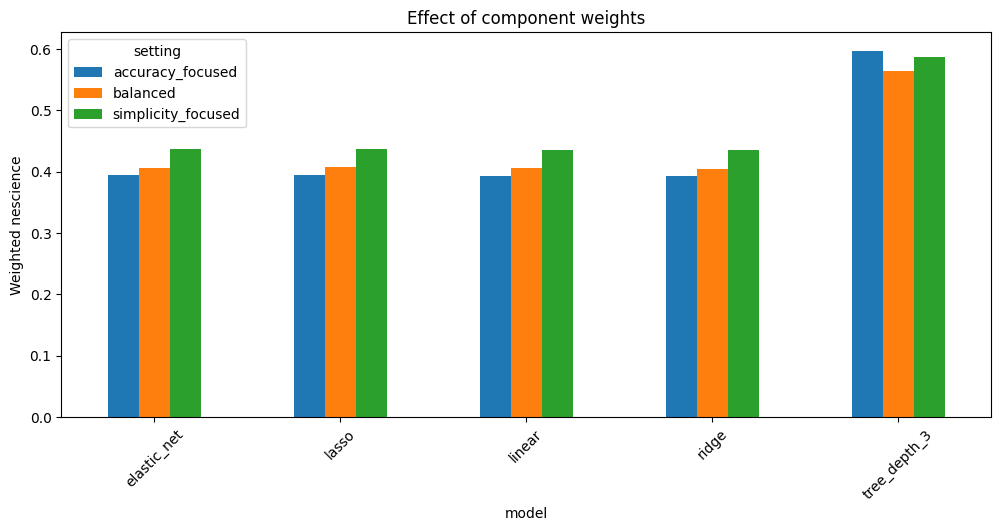

In [13]:
weighted_results.pivot(
    index="model",
    columns="setting",
    values="nescience",
).plot(kind="bar", figsize=(12, 5))

plt.ylabel("Weighted nescience")
plt.title("Effect of component weights")
plt.xticks(rotation=45)
plt.show()


## 8. Strict handling of unsupported models

Unsupported models should fail explicitly instead of silently assuming that all features are used. This is important because a wrong subset would corrupt the miscoding component.


In [14]:
dummy = DummyRegressor().fit(X_train, y_train)

try:
    sklearn_model_artifacts(dummy, X_test)
except NotImplementedError as exc:
    print(type(exc).__name__)
    print(exc)


NotImplementedError
No scikit-learn serializer registered for DummyRegressor.


## 9. Summary

The adapter layer makes the simplified `mnplib` design practical without compromising its separation of concerns.

The core metrics remain simple and explicit:

```python
metric.nescience(subset=..., predictions=..., model_string=...)
```

The scikit-learn adapter adds a practical bridge:

```python
sklearn_model_artifacts(model, X_eval)
nescience_model(metric, model, X_eval)
components_model(metric, model, X_eval)
explain_model(metric, model, X_eval)
score_model(metric, model, X_eval)
```

The most important design choice is the canonical serialization schema. It makes surfeit comparisons more meaningful than relying on heterogeneous model-specific string representations.
